In [2]:
#Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_DA_Belgium = df[(df['job_country'] == 'Belgium') & (df['job_title_short'] =='Data Analyst')]

df_DA_Belgium

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
148,Data Analyst,Tableau BI Developer,"Brussels, Belgium",via BR Proud Jobs,Contractor,False,Belgium,2023-03-02 13:14:19,True,False,Belgium,NaN,NaN,NaN,Apollo Solutions,"[python, sql, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
414,Data Analyst,informaticien,"Liège, Belgium",via Indeed,Full-time,False,Belgium,2023-11-24 13:54:09,False,False,Belgium,NaN,NaN,NaN,Randstad,"[sql, sql server, oracle, power bi]","{'analyst_tools': ['power bi'], 'cloud': ['ora..."
1045,Data Analyst,Data Analyst - Collibra,"Brussels, Belgium",via Indeed,Full-time,False,Belgium,2023-06-23 14:17:25,False,False,Belgium,NaN,NaN,NaN,AMA European Consulting,"[sql, azure, vue, excel]","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
1404,Data Analyst,Jr. Medical Data Analyst,"Brussels, Belgium",via Indeed,Full-time,False,Belgium,2023-03-03 13:11:58,False,False,Belgium,NaN,NaN,NaN,EarlyTracks,"[r, gdpr]","{'libraries': ['gdpr'], 'programming': ['r']}"
1553,Data Analyst,Data Analyst,"Antwerp, Belgium",via Indeed,Full-time,False,Belgium,2023-01-24 13:26:09,False,False,Belgium,NaN,NaN,NaN,One On One,"[t-sql, power bi]","{'analyst_tools': ['power bi'], 'programming':..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783235,Data Analyst,Digital data analyst,"Mechelen, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-31 06:26:26,True,False,Belgium,NaN,NaN,NaN,Telenet,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
783616,Data Analyst,Data Analyst Reporting,"Saint-Gilles, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-01 07:04:35,False,False,Belgium,NaN,NaN,NaN,Smals,"[sas, sas, vue, ssrs]","{'analyst_tools': ['sas', 'ssrs'], 'programmin..."
784219,Data Analyst,Statistical Scientist,"Mechelen, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-13 06:49:19,False,False,Belgium,NaN,NaN,NaN,ICON,NaN,NaN
784581,Data Analyst,data analyst,"Kortrijk, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-13 06:49:05,True,False,Belgium,NaN,NaN,NaN,Eyetech Solutions,NaN,NaN


In [12]:
df_DA_Belgium['job_location'].value_counts().head(10).to_frame()

,count
job_location,
"Brussels, Belgium",1284
Belgium,585
"Antwerp, Belgium",343
"Mechelen, Belgium",149
"Ghent, Belgium",123
Anywhere,91
"Zaventem, Belgium",88
"Leuven, Belgium",73
"Bruges, Belgium",40


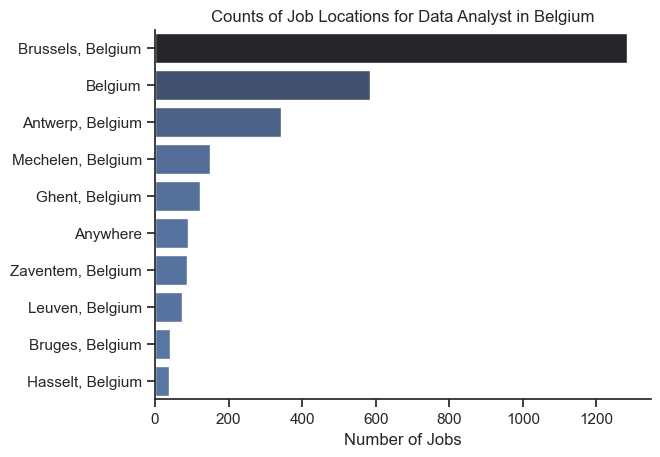

In [21]:
import seaborn as sns
df_plot = df_DA_Belgium['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in Belgium')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

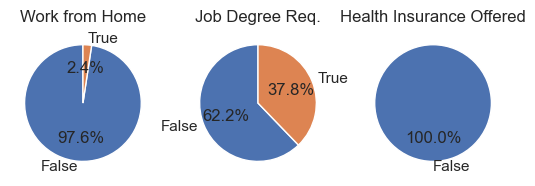

In [38]:
dict_column= {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention':'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)


for i, (column, title) in enumerate(dict_column.items()):   # (column, title) need to be wrapped inside parentheses, otherwise it'd return error
    ax[i].pie(df_DA_Belgium[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=df_DA_Belgium[column].value_counts().index)
    ax[i].set_title(title)
plt.show()

In [36]:
dict_column= {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention':'Job Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

for column, item in dict_column.items():
    print(df_DA_Belgium[column].value_counts())

job_work_from_home
False    3716
True       91
Name: count, dtype: int64
job_no_degree_mention
False    2368
True     1439
Name: count, dtype: int64
job_health_insurance
False    3807
Name: count, dtype: int64


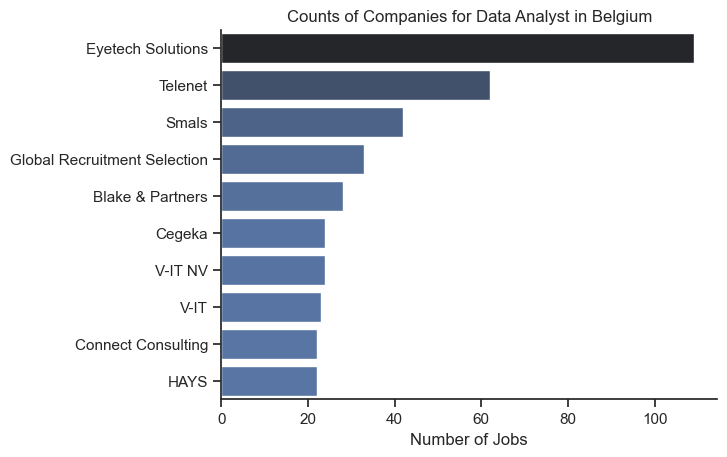

In [39]:
df_plot = df_DA_Belgium['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in Belgium')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()